# DINOv2 on Dollar Street: Is the Geographic/Income Bias in the Backbone or the Linear Probe?

**Testing Hypothesis 3** from the "Genuinely Testable Hypotheses" document.

DINOv2's own paper reports a 25.7-point accuracy drop on African vs. European images, and a
31.7-point drop for low- vs. high-income households, on the Dollar Street fairness benchmark —
and frames this as the backbone being "biased toward Western countries." But DINOv2's own
evaluation protocol only ever fits a **linear classifier on frozen features**; the backbone itself
is never fine-tuned. That leaves two very different possible causes bundled together in one number:

- **(a)** the self-supervised features genuinely don't encode enough information to tell
  underrepresented-region objects apart, or
- **(b)** the features are fine, but a class-balanced-but-not-region-balanced linear probe bakes
  regional/income skew into the decision boundary even though the underlying representation is
  unbiased.

This notebook isolates **(b)** without touching the DINOv2 backbone at all: we train two linear
probes on the *same frozen features* — one with standard class-balanced sampling, one with an
explicit region-and-income-stratified resample — and compare how much of the region/income
accuracy gap each one closes.

**Important scope note (stated up front, not buried in the limitations section):** this uses the
`nlphuji/dollar_street_test` Hugging Face mirror (1,600 images, object-`topics` labels, `region.id`
and `income` metadata), which is a genuine subset of the same Dollar Street dataset but is **not**
the exact ImageNet-mapped evaluation harness Meta used internally for the paper's headline numbers.
Treat this as a testable analogue that answers a narrower, well-posed question — not a literal
reproduction of the paper's 25.7-point figure.

In [1]:
# -- Install required packages --------------------------------------------
!pip install -q datasets transformers
print("Installed.")

Installed.


In [2]:
# -- Core imports -----------------------------------------------------------
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel

import warnings
warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE.upper()}")

Running on: CUDA


## 1 -- Load Dollar Street and build the classification task

We keep only object classes (`topics[0]`) with enough images to support a train/test split, and record each image's world region and an income bucket for the fairness breakdown later.

In [3]:
print("Loading nlphuji/dollar_street_test ...")

# Newer `datasets` releases (v4+) dropped support for repos that still ship a Python loading
# script, and this repo hasn't been migrated -- load_dataset("nlphuji/dollar_street_test")
# fails with "RuntimeError: Dataset scripts are no longer supported". The fix is to bypass the
# script entirely and load the Hub's auto-converted Parquet shards directly (every dataset gets
# these regardless of whether the repo itself has a script).
try:
    ds = load_dataset("nlphuji/dollar_street_test")["test"]
except RuntimeError as e:
    if "Dataset scripts are no longer supported" not in str(e):
        raise
    print("  (loading script unsupported in this datasets version -- falling back to the "
          "auto-converted Parquet shards on the 'refs/convert/parquet' branch)")
    parquet_glob = "hf://datasets/nlphuji/dollar_street_test@refs/convert/parquet/TEST/**/*.parquet"
    ds_dict = load_dataset("parquet", data_files=parquet_glob)
    # the generic "parquet" loader always names the split "train" regardless of the source's
    # original split name, so just grab whichever single split came back
    ds = ds_dict[list(ds_dict.keys())[0]]

print(f"Loaded {len(ds)} images.")
print(ds.features)

Loading nlphuji/dollar_street_test ...


README.md:   0%|          | 0.00/737 [00:00<?, ?B/s]

dollar_street_test.py:   0%|          | 0.00/2.96k [00:00<?, ?B/s]

  (loading script unsupported in this datasets version -- falling back to the auto-converted Parquet shards on the 'refs/convert/parquet' branch)


TEST/partial-test/0000.parquet: reconstructing file:   0%|          |  0.00B /  649MB            

...

TEST/partial-test/0006.parquet: downloading bytes:           |  0.00B            

TEST/partial-test/0007.parquet: reconstructing file:   0%|          |  0.00B /  597MB            

TEST/partial-test/0007.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 1600 images.
{'image': Image(mode=None, decode=True), 'id': Value('string'), 'country.id': Value('string'), 'country.name': Value('string'), 'region.id': Value('string'), 'type': Value('string'), 'imageRelPath': Value('string'), 'topics': List(Value('string')), 'place': Value('string'), 'income': Value('string'), 'imagenet_synonyms': List(Value('string')), 'imagenet_sysnet_id': List(Value('string')), 'image_name': Value('string')}


In [4]:
REGION_NAMES = {"af": "Africa", "am": "Americas", "as": "Asia", "eu": "Europe"}

def get_field(example, *candidates, default=None):
    '''Try several possible (possibly nested) field names -- HF dataset schemas sometimes
    flatten dotted columns into nested dicts depending on the loader version.'''
    for cand in candidates:
        if "." in cand:
            top, sub = cand.split(".", 1)
            if top in example and isinstance(example[top], dict) and sub in example[top]:
                return example[top][sub]
        if cand in example:
            return example[cand]
    return default

records = []
for i, ex in enumerate(ds):
    topics = get_field(ex, "topics", default=[])
    if not topics:
        continue
    label = topics[0]
    region_id = get_field(ex, "region.id", "region_id", "region", default="unknown")
    if isinstance(region_id, dict):
        region_id = region_id.get("id", "unknown")
    income_raw = get_field(ex, "income", default=None)
    try:
        income = float(income_raw)
    except (TypeError, ValueError):
        income = None
    if income is None:
        continue
    records.append({"idx": i, "label": label, "region_id": region_id, "income": income})

df = pd.DataFrame(records)
df["region"] = df["region_id"].map(REGION_NAMES).fillna("Unknown")
print(f"Usable images (valid topic + income + region): {len(df)}")
df.head()

Usable images (valid topic + income + region): 1600


,idx,label,region_id,income,region
0,0,tv,as,146.494165,Asia
1,1,tv,am,1098.831667,Americas
2,2,phone,as,96.000000,Asia
3,3,computer,am,3360.000000,Americas
4,4,bathroom/toilet,as,826.615810,Asia


In [5]:
# -- Keep only classes with enough images to support an 80/20 split ----------
MIN_PER_CLASS = 15
class_counts = df["label"].value_counts()
keep_classes = class_counts[class_counts >= MIN_PER_CLASS].index.tolist()
df = df[df["label"].isin(keep_classes)].reset_index(drop=True)

CLASS_NAMES = sorted(df["label"].unique().tolist())
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}
df["label_id"] = df["label"].map(CLASS_TO_ID)

print(f"Kept {len(CLASS_NAMES)} classes with >= {MIN_PER_CLASS} images: {CLASS_NAMES}")
print(f"Total usable images: {len(df)}")

# -- Income buckets: empirical tertiles (log-income), computed on this subset ----------------
df["log_income"] = np.log(df["income"].clip(lower=1.0))
q1, q2 = df["log_income"].quantile([1/3, 2/3])
def bucket_income(x):
    if x <= q1: return "low"
    if x <= q2: return "medium"
    return "high"
df["income_bucket"] = df["log_income"].apply(bucket_income)

print("\nRegion distribution:")
print(df["region"].value_counts())
print("\nIncome bucket distribution:")
print(df["income_bucket"].value_counts())
print("\nRegion x income_bucket cross-tab (small cells are expected -- flagged later):")
print(pd.crosstab(df["region"], df["income_bucket"]))

Kept 52 classes with >= 15 images: ['armchair', 'bathroom/toilet', 'bed', 'bike', 'books', 'ceiling', 'cleaning equipment', 'computer', 'cooking pots', 'cooking utensils', 'couch', 'cups/mugs/glasses', 'cutlery', 'dish racks', 'dish washing brush/cloth', 'dish washing soap', 'drinking water', 'everyday shoes', 'home', 'kitchen sink', 'light source in kitchen', 'light source in livingroom', 'lock on front door', 'medication', 'mosquito protection', 'paper', 'pen/pencils', 'phone', 'place where eating dinner', 'plate of food', 'plates', 'refrigerator', 'roof', 'salt', 'shower', 'soap for hands and body', 'social drink', 'source of cool', 'stove/hob', 'street detail', 'street view', 'switch on/off', 'table with food', 'toilet', 'toilet paper', 'tools', 'toys', 'trash/waste', 'tv', 'visit', 'wardrobe', 'washing clothes/cleaning']
Total usable images: 1351

Region distribution:
region
Asia        653
Americas    267
Africa      257
Europe      174
Name: count, dtype: int64

Income bucket di

---

## 2 -- Extract frozen DINOv2 features for every kept image

Same model choice as the `DINOv2_FewShot` notebook (`facebook/dinov2-small`), so results are directly comparable to the CIFAR-10 few-shot numbers already in the report.

In [6]:
MODEL_NAME = "facebook/dinov2-small"
print(f"Loading {MODEL_NAME} ...")
dino_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
dino_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
dino_model.eval()
EMBED_DIM = dino_model.config.hidden_size
print(f"Loaded. Embedding dim: {EMBED_DIM}")

Loading facebook/dinov2-small ...


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loaded. Embedding dim: 384


In [7]:
@torch.no_grad()
def extract_features(dataset, row_indices):
    feats = []
    for pos, row_idx in enumerate(row_indices):
        pil_img = dataset[int(row_idx)]["image"].convert("RGB")
        inputs = dino_processor(images=pil_img, return_tensors="pt").to(DEVICE)
        out = dino_model(**inputs)
        cls_feat = out.last_hidden_state[:, 0, :]
        cls_feat = F.normalize(cls_feat, dim=-1)
        feats.append(cls_feat.cpu())
        if (pos + 1) % 200 == 0:
            print(f"  extracted {pos + 1}/{len(row_indices)}")
    return torch.cat(feats, dim=0)

print(f"Extracting DINOv2 features for {len(df)} images (this is the slow cell, run once)...")
all_features = extract_features(ds, df["idx"].tolist())
print(f"Done. Feature matrix: {all_features.shape}")

Extracting DINOv2 features for 1351 images (this is the slow cell, run once)...
  extracted 200/1351
  extracted 400/1351
  extracted 600/1351
  extracted 800/1351
  extracted 1000/1351
  extracted 1200/1351
Done. Feature matrix: torch.Size([1351, 384])


---

## 3 -- Stratified train/test split (by class)

80/20 split, stratified so every kept class appears in both train and test.

In [8]:
def stratified_split(df, test_frac=0.2, seed=0):
    rng = np.random.RandomState(seed)
    train_pos, test_pos = [], []
    for label_id, group in df.groupby("label_id"):
        positions = group.index.to_numpy()
        rng.shuffle(positions)
        n_test = max(1, int(round(len(positions) * test_frac)))
        test_pos.extend(positions[:n_test].tolist())
        train_pos.extend(positions[n_test:].tolist())
    return np.array(train_pos), np.array(test_pos)

train_pos, test_pos = stratified_split(df)
print(f"Train: {len(train_pos)} images | Test: {len(test_pos)} images")

X_train_full = all_features[train_pos]
y_train_full = torch.tensor(df.loc[train_pos, "label_id"].to_numpy())
X_test = all_features[test_pos].to(DEVICE)
y_test = torch.tensor(df.loc[test_pos, "label_id"].to_numpy()).to(DEVICE)

train_df = df.loc[train_pos].reset_index(drop=True)
test_df = df.loc[test_pos].reset_index(drop=True)

Train: 1081 images | Test: 270 images


---

## 4 -- Probe A: standard linear probe (natural class-balanced-only sampling)

This mirrors what DINOv2's own paper does: fit a linear head on frozen features with no explicit region/income rebalancing.

In [9]:
class LinearProbe(torch.nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = torch.nn.Linear(input_dim, num_classes)
    def forward(self, x):
        return self.fc(x)


def train_linear_probe(X, y, num_classes, epochs=60, lr=1e-3, batch_size=64, weight_decay=1e-4):
    probe = LinearProbe(X.shape[1], num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(probe.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X.to(DEVICE), y.to(DEVICE)),
        batch_size=batch_size, shuffle=True)
    probe.train()
    for epoch in range(epochs):
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(probe(bx), by)
            loss.backward()
            optimizer.step()
    probe.eval()
    return probe


probe_A = train_linear_probe(X_train_full, y_train_full, num_classes=len(CLASS_NAMES))
print("Probe A (standard sampling) trained.")

Probe A (standard sampling) trained.


---

## 5 -- Probe B: region + income balanced resample

Within each class, we oversample (with replacement) so that every observed (region, income-bucket) combination is represented close to equally, up to a capped multiplier so no single rare cell explodes the effective training set size.

In [10]:
def balanced_resample_indices(sub_df, group_cols=("region", "income_bucket"), max_multiplier=5, seed=0):
    '''Returns a list of positions (into sub_df) resampled so groups within each class are
    balanced, capped at max_multiplier x the group's original count to avoid extreme duplication.'''
    rng = np.random.RandomState(seed)
    resampled = []
    for label_id, class_group in sub_df.groupby("label_id"):
        group_key = class_group[list(group_cols)].astype(str).agg("_".join, axis=1)
        counts = group_key.value_counts()
        target = counts.max()
        for key, count in counts.items():
            positions = class_group.index[group_key == key].to_numpy()
            n_target = min(target, count * max_multiplier)
            chosen = rng.choice(positions, size=int(n_target), replace=True)
            resampled.extend(chosen.tolist())
    return resampled


balanced_positions = balanced_resample_indices(train_df)
print(f"Balanced resample: {len(train_df)} -> {len(balanced_positions)} training examples "
      f"({len(balanced_positions) / len(train_df):.2f}x)")

# positions here are into train_df / X_train_full (same index space)
X_train_balanced = X_train_full[balanced_positions]
y_train_balanced = y_train_full[balanced_positions]

probe_B = train_linear_probe(X_train_balanced, y_train_balanced, num_classes=len(CLASS_NAMES))
print("Probe B (region+income balanced resample) trained.")

Balanced resample: 1081 -> 2136 training examples (1.98x)
Probe B (region+income balanced resample) trained.


---

## 6 -- Evaluate both probes, broken down by region and income bucket

In [11]:
@torch.no_grad()
def evaluate_breakdown(probe, X, y, meta_df, group_col):
    preds = probe(X).argmax(dim=1).cpu().numpy()
    y_np = y.cpu().numpy()
    correct = (preds == y_np)
    overall = correct.mean() * 100

    breakdown = {}
    for group_val, sub in meta_df.groupby(group_col):
        mask = sub.index.to_numpy()
        if len(mask) == 0:
            continue
        breakdown[group_val] = correct[mask].mean() * 100
    return overall, breakdown


def summarize(probe, name):
    overall, region_acc = evaluate_breakdown(probe, X_test, y_test, test_df, "region")
    _, income_acc = evaluate_breakdown(probe, X_test, y_test, test_df, "income_bucket")

    region_gap = max(region_acc.values()) - min(region_acc.values()) if len(region_acc) > 1 else float('nan')
    income_gap = max(income_acc.values()) - min(income_acc.values()) if len(income_acc) > 1 else float('nan')

    print(f"\n=== {name} ===")
    print(f"Overall test accuracy: {overall:.1f}%")
    print("By region:")
    for r, a in sorted(region_acc.items(), key=lambda x: -x[1]):
        n = (test_df['region'] == r).sum()
        print(f"    {r:>10}: {a:5.1f}%  (n={n})")
    print(f"  Region gap (max-min): {region_gap:.1f} pts")
    print("By income bucket:")
    for b, a in sorted(income_acc.items(), key=lambda x: -x[1]):
        n = (test_df['income_bucket'] == b).sum()
        print(f"    {b:>10}: {a:5.1f}%  (n={n})")
    print(f"  Income gap (max-min): {income_gap:.1f} pts")

    return {"overall": overall, "region_acc": region_acc, "income_acc": income_acc,
            "region_gap": region_gap, "income_gap": income_gap}


results_A = summarize(probe_A, "Probe A: standard sampling")
results_B = summarize(probe_B, "Probe B: region+income balanced resample")


=== Probe A: standard sampling ===
Overall test accuracy: 64.8%
By region:
      Americas:  73.9%  (n=46)
        Europe:  65.9%  (n=41)
          Asia:  64.8%  (n=125)
        Africa:  56.9%  (n=58)
  Region gap (max-min): 17.0 pts
By income bucket:
          high:  72.3%  (n=101)
        medium:  65.2%  (n=89)
           low:  55.0%  (n=80)
  Income gap (max-min): 17.3 pts

=== Probe B: region+income balanced resample ===
Overall test accuracy: 63.3%
By region:
      Americas:  71.7%  (n=46)
          Asia:  64.0%  (n=125)
        Europe:  63.4%  (n=41)
        Africa:  55.2%  (n=58)
  Region gap (max-min): 16.6 pts
By income bucket:
          high:  73.3%  (n=101)
        medium:  68.5%  (n=89)
           low:  45.0%  (n=80)
  Income gap (max-min): 28.3 pts


In [12]:
# -- Gap-closing summary -----------------------------------------------------
def pct_closed(before, after):
    if before == 0:
        return float('nan')
    return (before - after) / before * 100

region_closed = pct_closed(results_A["region_gap"], results_B["region_gap"])
income_closed = pct_closed(results_A["income_gap"], results_B["income_gap"])

print(f"{'':>22} {'Probe A (standard)':>20} {'Probe B (balanced)':>20} {'% of gap closed':>18}")
print("-" * 84)
print(f"{'Overall accuracy':>22} {results_A['overall']:>19.1f}% {results_B['overall']:>19.1f}% {'--':>18}")
print(f"{'Region gap':>22} {results_A['region_gap']:>19.1f} {results_B['region_gap']:>19.1f} {region_closed:>17.1f}%")
print(f"{'Income gap':>22} {results_A['income_gap']:>19.1f} {results_B['income_gap']:>19.1f} {income_closed:>17.1f}%")

                         Probe A (standard)   Probe B (balanced)    % of gap closed
------------------------------------------------------------------------------------
      Overall accuracy                64.8%                63.3%                 --
            Region gap                17.0                16.6               2.6%
            Income gap                17.3                28.3             -63.6%


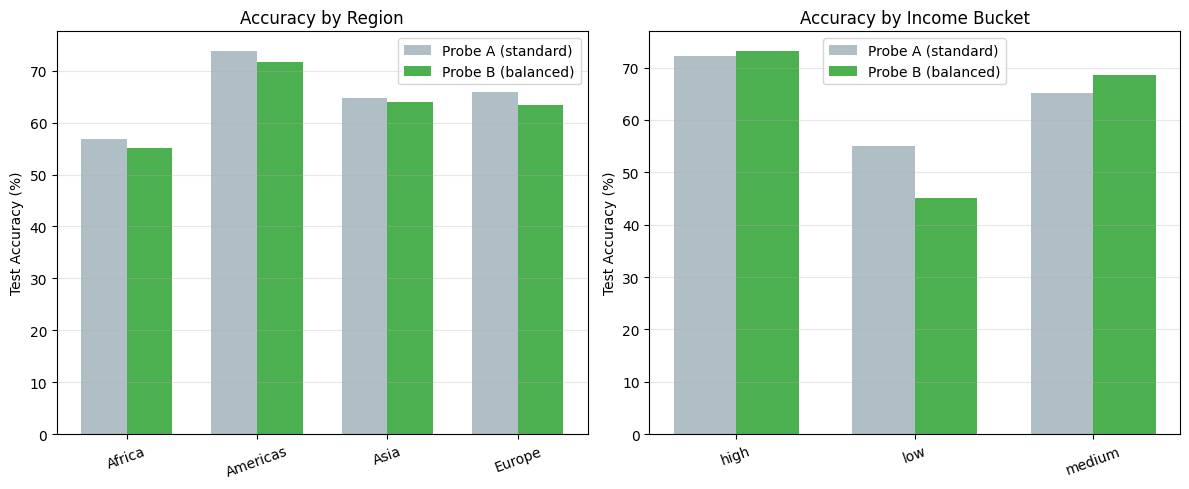

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (title, acc_a, acc_b) in zip(
    axes,
    [("Accuracy by Region", results_A["region_acc"], results_B["region_acc"]),
     ("Accuracy by Income Bucket", results_A["income_acc"], results_B["income_acc"])]
):
    keys = sorted(set(acc_a.keys()) | set(acc_b.keys()))
    x = np.arange(len(keys))
    width = 0.35
    ax.bar(x - width/2, [acc_a.get(k, 0) for k in keys], width, label='Probe A (standard)', color='#B0BEC5')
    ax.bar(x + width/2, [acc_b.get(k, 0) for k in keys], width, label='Probe B (balanced)', color='#4CAF50')
    ax.set_xticks(x)
    ax.set_xticklabels(keys, rotation=20)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dinov2_bias_probe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7 -- Interpreting the result (per Hypothesis 3's own falsification criterion)

- **If Probe B closes most of the region/income gap** (high "% of gap closed" above) while using the
  *exact same frozen DINOv2 features* as Probe A: this supports the hypothesis that a meaningful part
  of the reported bias comes from **imbalanced linear-probe training**, not from the backbone's
  self-supervised representation itself -- a cheaper, more actionable finding than "the backbone
  is biased," since it implies fairness gains are available without retraining a foundation model.

- **If the gap barely moves even with a fully balanced resample:** report this as a genuine negative
  result, not a failed experiment. It means the frozen features don't linearly separate
  underrepresented-region/income classes well, which points back toward the backbone/pretraining-data
  explanation this notebook was designed to help rule in or out. Say so plainly in the writeup rather
  than only reporting a positive result.

**What this experiment does *not* claim:** a linear probe can only recover what's already linearly
present in the frozen features. A small gap-reduction here doesn't prove the backbone is fully
unbiased at some deeper, non-linear level -- it answers the narrower, well-posed question of whether
*this specific gap number, under DINOv2's own published evaluation protocol (linear probe on frozen
features)*, is attributable to classifier-training imbalance vs. feature quality. That's the honest
scope Hypothesis 3 was written to have.

**Caveats to state alongside any numbers you report:**
- Some (region, income-bucket) cells are small (see the cross-tab in Section 1) -- the balanced
  resample's oversampling multiplier is capped at 5x specifically to avoid a handful of images
  dominating Probe B's training signal; report this cap alongside your results.
- This uses `nlphuji/dollar_street_test`'s `topics` labels directly rather than DINOv2's paper's
  ImageNet-mapped taxonomy, so absolute accuracy numbers are not comparable to the paper's; only the
  **within-notebook gap comparison (Probe A vs. Probe B)** is the intended takeaway.

**Suggested use in the report:** this extends Chapter 7 (Ethical, Social, and Environmental
Considerations) beyond the current one-paragraph acknowledgment of VLM bias, and gives Future Work
(9.2) a concrete, already-executed first step toward the fairness angle of few-shot foundation-model
deployment, rather than only listing it as a direction.

In [14]:
print("Region x income_bucket cross-tab (test split only, for reference):")
print(pd.crosstab(test_df["region"], test_df["income_bucket"]))

print("\nRegion x income_bucket cross-tab (full kept dataset):")
crosstab_full = pd.crosstab(df["region"], df["income_bucket"])
print(crosstab_full)

# Cramer's V as a simple, self-contained confound-strength check (0 = independent, 1 = fully confounded)
chi2 = 0.0
row_totals = crosstab_full.sum(axis=1)
col_totals = crosstab_full.sum(axis=0)
n_total = crosstab_full.values.sum()
for r in crosstab_full.index:
    for c in crosstab_full.columns:
        observed = crosstab_full.loc[r, c]
        expected = row_totals[r] * col_totals[c] / n_total
        if expected > 0:
            chi2 += (observed - expected) ** 2 / expected
n_rows, n_cols = crosstab_full.shape
cramers_v = np.sqrt(chi2 / (n_total * (min(n_rows, n_cols) - 1)))
print(f"\nCramer's V (region vs. income_bucket): {cramers_v:.2f}  "
      f"({'strongly confounded' if cramers_v > 0.3 else 'weakly/moderately associated'} "
      f"-- 0 = independent, 1 = fully determined by each other)")

Region x income_bucket cross-tab (test split only, for reference):
income_bucket  high  low  medium
region                          
Africa            7   37      14
Americas         24    5      17
Asia             39   36      50
Europe           31    2       8

Region x income_bucket cross-tab (full kept dataset):
income_bucket  high  low  medium
region                          
Africa           25  174      58
Americas        108   47     112
Asia            175  232     246
Europe          143    3      28

Cramer's V (region vs. income_bucket): 0.37  (strongly confounded -- 0 = independent, 1 = fully determined by each other)


In [16]:
def balanced_resample_indices(sub_df, group_cols, max_multiplier=5, seed=0):
    '''Returns a list of positions (into sub_df) resampled so groups within each class are
    balanced, capped at max_multiplier x the group's original count to avoid extreme duplication.'''
    rng = np.random.RandomState(seed)
    resampled = []
    for label_id, class_group in sub_df.groupby("label_id"):
        group_key = class_group[list(group_cols)].astype(str).agg("_".join, axis=1)
        counts = group_key.value_counts()
        target = counts.max()
        for key, count in counts.items():
            positions = class_group.index[group_key == key].to_numpy()
            n_target = min(target, count * max_multiplier)
            chosen = rng.choice(positions, size=int(n_target), replace=True)
            resampled.extend(chosen.tolist())
    return resampled


def resample_and_train(group_cols, label):
    positions = balanced_resample_indices(train_df, group_cols=group_cols)
    print(f"{label}: {len(train_df)} -> {len(positions)} training examples "
          f"({len(positions) / len(train_df):.2f}x)")
    X_bal = X_train_full[positions]
    y_bal = y_train_full[positions]
    probe = train_linear_probe(X_bal, y_bal, num_classes=len(CLASS_NAMES))
    return probe


probe_B = resample_and_train(("region", "income_bucket"), "Probe B (joint region+income balanced)")
probe_C = resample_and_train(("region",), "Probe C (region-only balanced)")
probe_D = resample_and_train(("income_bucket",), "Probe D (income-only balanced)")
print("All three balanced probes trained.")

Probe B (joint region+income balanced): 1081 -> 2136 training examples (1.98x)
Probe C (region-only balanced): 1081 -> 1925 training examples (1.78x)
Probe D (income-only balanced): 1081 -> 1479 training examples (1.37x)
All three balanced probes trained.


In [17]:
@torch.no_grad()
def evaluate_breakdown(probe, X, y, meta_df, group_col):
    preds = probe(X).argmax(dim=1).cpu().numpy()
    y_np = y.cpu().numpy()
    correct = (preds == y_np)
    overall = correct.mean() * 100

    breakdown = {}
    for group_val, sub in meta_df.groupby(group_col):
        mask = sub.index.to_numpy()
        if len(mask) == 0:
            continue
        breakdown[group_val] = correct[mask].mean() * 100
    return overall, breakdown


def summarize(probe, name):
    overall, region_acc = evaluate_breakdown(probe, X_test, y_test, test_df, "region")
    _, income_acc = evaluate_breakdown(probe, X_test, y_test, test_df, "income_bucket")

    region_gap = max(region_acc.values()) - min(region_acc.values()) if len(region_acc) > 1 else float('nan')
    income_gap = max(income_acc.values()) - min(income_acc.values()) if len(income_acc) > 1 else float('nan')

    print(f"\n=== {name} ===")
    print(f"Overall test accuracy: {overall:.1f}%")
    print("By region:")
    for r, a in sorted(region_acc.items(), key=lambda x: -x[1]):
        n = (test_df['region'] == r).sum()
        print(f"    {r:>10}: {a:5.1f}%  (n={n})")
    print(f"  Region gap (max-min): {region_gap:.1f} pts")
    print("By income bucket:")
    for b, a in sorted(income_acc.items(), key=lambda x: -x[1]):
        n = (test_df['income_bucket'] == b).sum()
        print(f"    {b:>10}: {a:5.1f}%  (n={n})")
    print(f"  Income gap (max-min): {income_gap:.1f} pts")

    return {"overall": overall, "region_acc": region_acc, "income_acc": income_acc,
            "region_gap": region_gap, "income_gap": income_gap}


results_A = summarize(probe_A, "Probe A: standard sampling")
results_B = summarize(probe_B, "Probe B: joint region+income balanced")
results_C = summarize(probe_C, "Probe C: region-only balanced")
results_D = summarize(probe_D, "Probe D: income-only balanced")


=== Probe A: standard sampling ===
Overall test accuracy: 64.8%
By region:
      Americas:  73.9%  (n=46)
        Europe:  65.9%  (n=41)
          Asia:  64.8%  (n=125)
        Africa:  56.9%  (n=58)
  Region gap (max-min): 17.0 pts
By income bucket:
          high:  72.3%  (n=101)
        medium:  65.2%  (n=89)
           low:  55.0%  (n=80)
  Income gap (max-min): 17.3 pts

=== Probe B: joint region+income balanced ===
Overall test accuracy: 63.0%
By region:
      Americas:  71.7%  (n=46)
          Asia:  64.0%  (n=125)
        Europe:  63.4%  (n=41)
        Africa:  53.4%  (n=58)
  Region gap (max-min): 18.3 pts
By income bucket:
          high:  73.3%  (n=101)
        medium:  67.4%  (n=89)
           low:  45.0%  (n=80)
  Income gap (max-min): 28.3 pts

=== Probe C: region-only balanced ===
Overall test accuracy: 63.0%
By region:
      Americas:  67.4%  (n=46)
        Africa:  67.2%  (n=58)
        Europe:  61.0%  (n=41)
          Asia:  60.0%  (n=125)
  Region gap (max-min): 7.4

In [18]:
# -- Gap-closing summary across all three balancing strategies ---------------
def pct_closed(before, after):
    if before == 0:
        return float('nan')
    return (before - after) / before * 100

rows = [
    ("Probe B (joint)",        results_B),
    ("Probe C (region-only)",  results_C),
    ("Probe D (income-only)",  results_D),
]

print(f"{'Probe':>22} {'Region gap':>12} {'% closed':>10} {'Income gap':>12} {'% closed':>10}")
print("-" * 70)
print(f"{'A: standard (baseline)':>22} {results_A['region_gap']:>11.1f} {'--':>10} "
      f"{results_A['income_gap']:>11.1f} {'--':>10}")
for name, res in rows:
    rc = pct_closed(results_A["region_gap"], res["region_gap"])
    ic = pct_closed(results_A["income_gap"], res["income_gap"])
    print(f"{name:>22} {res['region_gap']:>11.1f} {rc:>9.1f}% {res['income_gap']:>11.1f} {ic:>9.1f}%")

                 Probe   Region gap   % closed   Income gap   % closed
----------------------------------------------------------------------
A: standard (baseline)        17.0         --        17.3         --
       Probe B (joint)        18.3      -7.5%        28.3     -63.6%
 Probe C (region-only)         7.4      56.6%        15.8       8.5%
 Probe D (income-only)        23.9     -40.5%        20.3     -17.5%


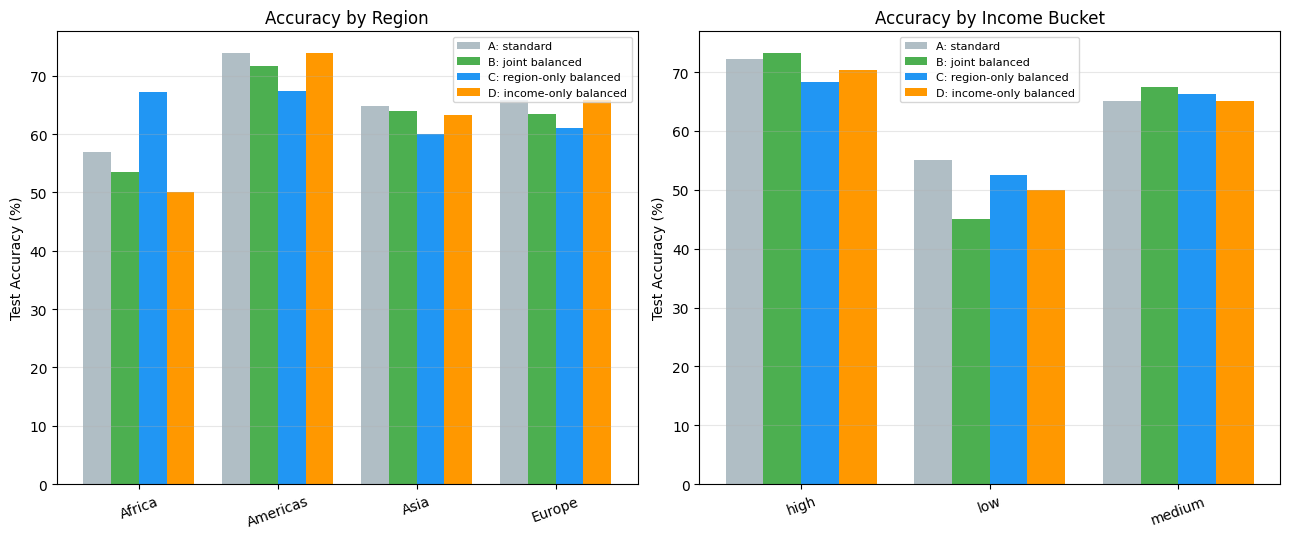

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
probes = [("A: standard", results_A, '#B0BEC5'),
          ("B: joint balanced", results_B, '#4CAF50'),
          ("C: region-only balanced", results_C, '#2196F3'),
          ("D: income-only balanced", results_D, '#FF9800')]

for ax, (title, acc_key) in zip(axes, [("Accuracy by Region", "region_acc"),
                                        ("Accuracy by Income Bucket", "income_acc")]):
    all_keys = sorted(set().union(*[r[acc_key].keys() for _, r, _ in probes]))
    x = np.arange(len(all_keys))
    width = 0.2
    for i, (label, res, color) in enumerate(probes):
        offset = (i - 1.5) * width
        ax.bar(x + offset, [res[acc_key].get(k, 0) for k in all_keys], width, label=label, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(all_keys, rotation=20)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dinov2_bias_probe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()